In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df = pd.read_csv('../data/raw/clinical_trials_data.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (2000, 12)
Columns: ['nct_id', 'start_year', 'disease_area', 'phase', 'status', 'intervention_type', 'lead_sponsor', 'enrollment', 'duration_months', 'ai_designed', 'multinational', 'has_biomarker']


,nct_id,start_year,disease_area,phase,status,intervention_type,lead_sponsor,enrollment,duration_months,ai_designed,multinational,has_biomarker
0,NCT2013000000,2019,Other,Phase 2,Withdrawn,Biological,AstraZeneca,46,29,False,True,True
1,NCT2013000001,2016,Diabetes/Metabolic,Phase 1,"Active, not recruiting",Drug,Bristol-Myers Squibb,63,19,False,False,True
2,NCT2013000002,2023,Diabetes/Metabolic,Phase 4,Recruiting,Behavioral,Biotech Startup,31,54,False,True,False
3,NCT2013000003,2020,Infectious Disease,Phase 4,"Active, not recruiting",Drug,AbbVie,252,10,False,True,True
4,NCT2013000004,2017,Neurology,NaN,Completed,Behavioral,Sanofi,205,17,False,False,False


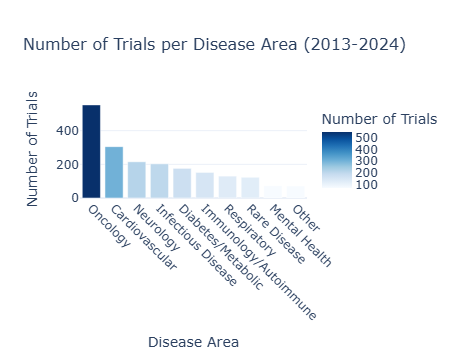

In [2]:
# Chart 1: Disease Area Distribution
disease_counts = df['disease_area'].value_counts().reset_index()
disease_counts.columns = ['disease_area', 'count']

fig = px.bar(disease_counts, 
             x='disease_area', 
             y='count',
             title='Number of Trials per Disease Area (2013-2024)',
             labels={'disease_area': 'Disease Area', 'count': 'Number of Trials'},
             template='plotly_white',
             color='count',
             color_continuous_scale='Blues')

fig.update_xaxes(tickangle=45)
fig.update_layout(title_font_size=16, showlegend=False)
fig.show()

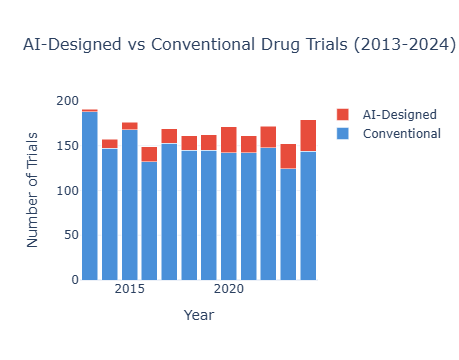


AI % by year:
    start_year  ai_count  total  ai_pct
0         2013         3    191     1.6
1         2014        10    157     6.4
2         2015         8    176     4.5
3         2016        17    149    11.4
4         2017        16    169     9.5
5         2018        16    161     9.9
6         2019        17    162    10.5
7         2020        29    171    17.0
8         2021        19    161    11.8
9         2022        24    172    14.0
10        2023        28    152    18.4
11        2024        35    179    19.6


In [3]:
# Chart 2: AI vs Conventional Trials over time
ai_trend = df.groupby('start_year').agg(
    total=('nct_id', 'count'),
    ai_count=('ai_designed', 'sum')
).reset_index()
ai_trend['conventional'] = ai_trend['total'] - ai_trend['ai_count']

fig = go.Figure()
fig.add_trace(go.Bar(x=ai_trend['start_year'], y=ai_trend['conventional'],
                     name='Conventional', marker_color='#4a90d9'))
fig.add_trace(go.Bar(x=ai_trend['start_year'], y=ai_trend['ai_count'],
                     name='AI-Designed', marker_color='#e74c3c'))

fig.update_layout(barmode='stack',
                  title='AI-Designed vs Conventional Drug Trials (2013-2024)',
                  xaxis_title='Year',
                  yaxis_title='Number of Trials',
                  template='plotly_white',
                  title_font_size=16)
fig.show()

print("\nAI % by year:")
ai_trend['ai_pct'] = (ai_trend['ai_count'] / ai_trend['total'] * 100).round(1)
print(ai_trend[['start_year', 'ai_count', 'total', 'ai_pct']])

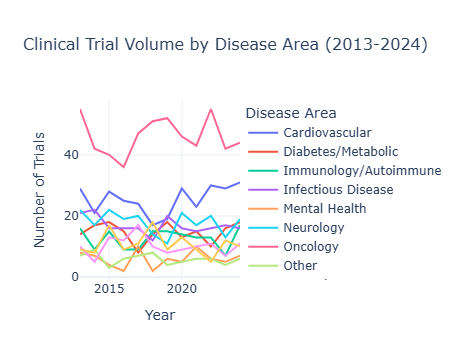

In [4]:
# Chart 3: Trial Volume Trend by Disease Area
trend = df.groupby(['start_year', 'disease_area']).size().reset_index(name='count')

fig = px.line(trend, x='start_year', y='count', color='disease_area',
              title='Clinical Trial Volume by Disease Area (2013-2024)',
              labels={'start_year': 'Year', 'count': 'Number of Trials', 
                      'disease_area': 'Disease Area'},
              template='plotly_white')

fig.update_layout(title_font_size=16)
fig.show()

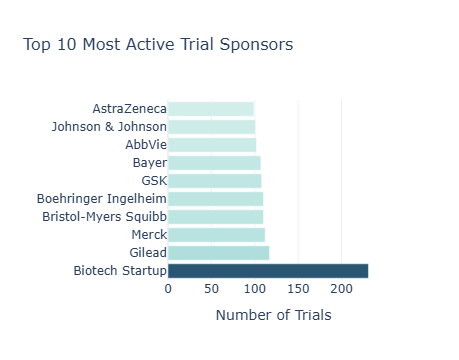

In [5]:
# Chart 4: Top 10 Sponsors
top_sponsors = df['lead_sponsor'].value_counts().head(10).reset_index()
top_sponsors.columns = ['sponsor', 'count']

fig = px.bar(top_sponsors, x='count', y='sponsor', orientation='h',
             title='Top 10 Most Active Trial Sponsors',
             labels={'count': 'Number of Trials', 'sponsor': ''},
             template='plotly_white',
             color='count', color_continuous_scale='Teal')

fig.update_layout(title_font_size=16, coloraxis_showscale=False)
fig.show()

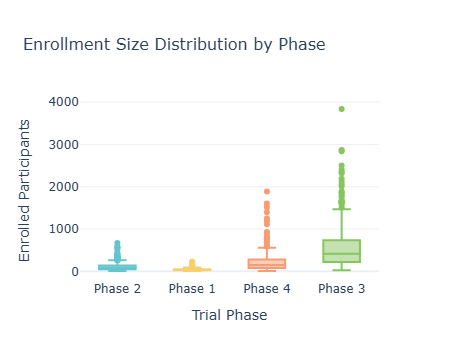


Median enrollment by phase:
phase
Phase 1     32.0
Phase 2     83.0
Phase 3    416.0
Phase 4    149.0
Name: enrollment, dtype: float64


In [6]:
# Chart 5: Enrollment Distribution by Phase
fig = px.box(df[df['enrollment'] < 10000], 
             x='phase', y='enrollment',
             title='Enrollment Size Distribution by Phase',
             labels={'phase': 'Trial Phase', 'enrollment': 'Enrolled Participants'},
             template='plotly_white',
             color='phase',
             color_discrete_sequence=px.colors.qualitative.Pastel)

fig.update_layout(title_font_size=16, showlegend=False)
fig.show()

print("\nMedian enrollment by phase:")
print(df.groupby('phase')['enrollment'].median().round(0))